# 1. Compiling the Dataset and Engineering Features

### Data Cleaning / Combining into DataFrame used in model training

First, we read in the 'labels' - hourly energy demand. Our analysis will focus on the load zone 'COAS', which includes Houston, TX. See the image below for reference (Coast).

<img src="https://www.ercot.com/files/assets/2023/04/26/Weather.jpg?" width="50%">


In [764]:
import pandas as pd
import numpy as np

df_demand = pd.read_csv("../ercot_demand.csv")
df_demand["period"] = pd.to_datetime(df_demand["period"])
df_demand.head()

,period,COAS,EAST,FWES,NCEN,NRTH,SCEN,SOUT,WEST
0,2023-06-01 00:00:00,17008.0,2373.0,5998.0,20016.0,1692.0,11267.0,5320.0,1712.0
1,2023-06-01 01:00:00,16423.0,2247.0,5964.0,19076.0,1681.0,10901.0,5135.0,1502.0
2,2023-06-01 02:00:00,15935.0,2122.0,5921.0,18104.0,1615.0,10416.0,4956.0,1408.0
3,2023-06-01 03:00:00,15387.0,2025.0,5980.0,17320.0,1550.0,10007.0,4804.0,1352.0
4,2023-06-01 04:00:00,14520.0,1885.0,5876.0,16056.0,1442.0,9321.0,4457.0,1337.0


To verify our import worked and the data looks good, we can plot a random week in the year.

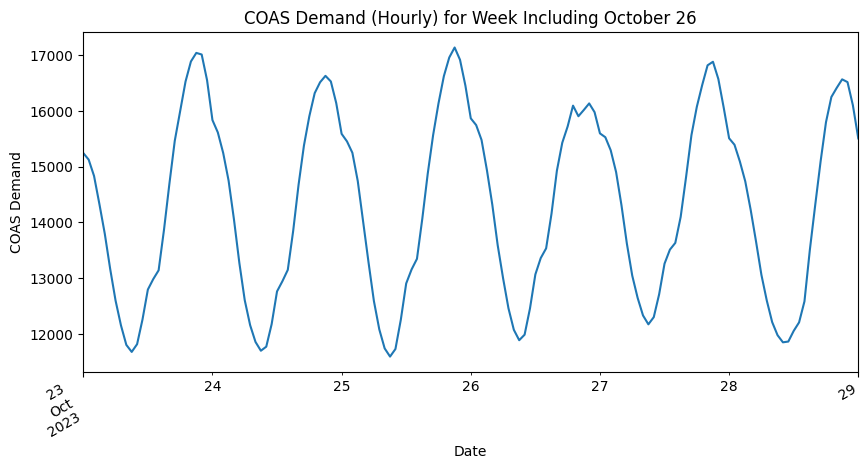

In [765]:
df_demand_oct = df_demand[df_demand["period"].dt.month == 10]
# Find the monday-sunday week in October that includes October 26
oct_26 = df_demand_oct[df_demand_oct["period"].dt.day == 26].iloc[0]["period"]
start_of_week = oct_26 - pd.Timedelta(days=oct_26.dayofweek)  # Monday of the week
end_of_week = start_of_week + pd.Timedelta(days=6)  # Sunday of the week
df_demand_week = df_demand_oct[
    (df_demand_oct["period"] >= start_of_week) &
    (df_demand_oct["period"] <= end_of_week)
]

import matplotlib.dates as mdates

ax = df_demand_week.set_index("period")["COAS"].plot(figsize=(10, 5))
ax.set_xlabel("Date")
ax.set_ylabel("COAS Demand")
ax.set_title("COAS Demand (Hourly) for Week Including October 26")
ax.figure.autofmt_xdate()






Next, we import weather data. This file contains data for weather predictions at the time instead of the actual weather to ensure fairness with ERCOTs model.

In [766]:
df_fair_weather = pd.read_csv("HoustonWeat.csv")
df_fair_weather.columns = df_fair_weather.columns.str.strip()

df_fair_weather.head()

# Convert to datetime
df_fair_weather['runtime'] = pd.to_datetime(df_fair_weather['runtime'])
df_fair_weather['ftime'] = pd.to_datetime(df_fair_weather['ftime'])

# 1. Filter for Day-Ahead Fairness (12 UTC run, looking 12 to 40 hours ahead)
df_fair_weather['horizon'] = df_fair_weather['ftime'] - df_fair_weather['runtime']
df_da = df_fair_weather[
    (df_fair_weather['runtime'].dt.hour == 12) &
    (df_fair_weather['horizon'] >= pd.Timedelta(hours=12)) &
    (df_fair_weather['horizon'] <= pd.Timedelta(hours=40))
].copy()

# 2. Updated renaming to include snow (if available in MOS)
df_da = df_da[['ftime', 'tmp', 'dpt', 'snw']].rename(columns={
    'ftime': 'valid',
    'tmp': 'tmpf',
    'dpt': 'dwpf',
    'snw': 'snowdepth'
})
df_da = df_da.drop_duplicates(subset=['valid'])

# 3. Interpolate 3-hour MOS data into hourly data
df_weather = df_da.set_index('valid').resample('h').interpolate(method='linear').reset_index()

df_weather.head()

,valid,tmpf,dwpf,snowdepth
0,2023-06-02 00:00:00,80.000000,67.000000,NaN
1,2023-06-02 01:00:00,78.000000,67.333333,NaN
2,2023-06-02 02:00:00,76.000000,67.666667,NaN
3,2023-06-02 03:00:00,74.000000,68.000000,NaN
4,2023-06-02 04:00:00,73.333333,68.000000,NaN


The type of day (school day, school holiday but workday, weekend, etc) may influence energy consumption patterns as well. Hence we import [Houston's school district calendar](https://www.fox26houston.com/news/houston-isd-calendar-for-2023-2024-academic-school-year-updated-released)

In [767]:
df_calendar = pd.read_csv('../hisd_2023_2024_day_categories_with_business(1).csv')
df_calendar.head()

,day,school_category,business_category
0,2023-06-01,summer_break_weekday,normal_business_day
1,2023-06-02,summer_break_weekday,normal_business_day
2,2023-06-03,weekend_school_break,weekend
3,2023-06-04,weekend_school_break,weekend
4,2023-06-05,summer_break_weekday,normal_business_day


We then look at the Houston Texans, the largest sports team in Houston, and scrape their website to obtain all the relevant games.

In [768]:
import requests, json
from bs4 import BeautifulSoup

resp = requests.get("https://www.houstontexans.com/schedule/2023/")
soup = BeautifulSoup(resp.text, "html.parser")
games = []
for script in soup.find_all("script", type="application/ld+json"):
    data = json.loads(script.string)
    if data.get("@type") == "SportsEvent":
        is_home = data["homeTeam"]["name"] == "Houston Texans"
        opponent = data["awayTeam"]["name"] if is_home else data["homeTeam"]["name"]
        games.append({
            "datetime": data["startDate"],
            "end_datetime": data["endDate"],
            "location": "home" if is_home else "away",
            "opponent": opponent,
        })

df_texans = pd.DataFrame(games)
df_texans["datetime"] = pd.to_datetime(df_texans["datetime"])
df_texans["end_datetime"] = pd.to_datetime(df_texans["end_datetime"])
df_texans = df_texans.sort_values("datetime").reset_index(drop=True)
df_texans

,datetime,end_datetime,location,opponent
0,2023-08-10 23:00:00,2023-08-11 02:30:00,away,New England Patriots
1,2023-08-19 20:00:00,2023-08-19 23:30:00,home,Miami Dolphins
2,2023-08-28 00:00:00,2023-08-28 03:30:00,away,New Orleans Saints
3,2023-09-10 17:00:00,2023-09-10 20:30:00,away,Baltimore Ravens
4,2023-09-17 17:00:00,2023-09-17 20:30:00,home,Indianapolis Colts
5,2023-09-24 17:00:00,2023-09-24 20:30:00,away,Jacksonville Jaguars
6,2023-10-01 17:00:00,2023-10-01 20:30:00,home,Pittsburgh Steelers
7,2023-10-08 17:00:00,2023-10-08 20:30:00,away,Atlanta Falcons
8,2023-10-15 17:00:00,2023-10-15 20:30:00,home,New Orleans Saints
9,2023-10-29 17:00:00,2023-10-29 20:30:00,away,Carolina Panthers


Now that we have gathered all relevant data, we combine the datasets into one DataFrame. The below cell builds a single hourly dataset (df_final) that combines COAS demand with calendar, federal holidays, Texans gamedays, Houston/Beaumont/Galveston weather, and lagged Houston BTM solar capacity.

In [769]:
# Process Holidays
df_holidays = pd.read_csv("FedHolidays.csv")
df_holidays['date'] = pd.to_datetime(df_holidays['date'])
df_holidays['is_holiday'] = 1

# Process BTM Solar
df_solar = pd.read_csv("Houston_BtmSolar_Combined.csv")
df_solar = df_solar[df_solar['Load_Zone'] == 'LZ_HOUSTON'].copy()
df_solar['year'] = df_solar['Reporting_Period'].str[:4].astype(int)
df_solar['quarter'] = df_solar['Reporting_Period'].str[-1].astype(int)

# Standardize date columns for merging
df_calendar['day'] = pd.to_datetime(df_calendar['day'])
df_weather['valid'] = pd.to_datetime(df_weather['valid'])

# Initialize and Merge Calendar & Holidays
df_final = df_demand[['period', 'COAS']].copy()
df_final['date_key'] = df_final['period'].dt.normalize()
df_final = df_final.merge(df_calendar, left_on='date_key', right_on='day', how='left')
df_final = df_final.merge(df_holidays[['date', 'is_holiday']], left_on='date_key', right_on='date', how='left')
df_final['is_holiday'] = df_final['is_holiday'].fillna(0)

# Process and merge Texans Schedule
df_texans['game_date'] = df_texans['datetime'].dt.normalize()
df_texans['is_texans_gameday'] = 1

df_final = df_final.merge(df_texans[['game_date', 'is_texans_gameday']].drop_duplicates(),
                          left_on='date_key', right_on='game_date', how='left')
df_final['is_texans_gameday'] = df_final['is_texans_gameday'].fillna(0)

# Merge Weather (Houston only)
weather_hourly = df_weather.groupby(df_weather['valid'].dt.floor('h')).mean(numeric_only=True).reset_index()
df_final = df_final.merge(weather_hourly, left_on='period', right_on='valid', how='left')

# Rolling 48-hour average temperature - using ACTUAL temperature
# 1) Load actual ASOS weather and aggregate to hourly tmpf
df_asos = pd.read_csv("../asos.csv")
df_asos["valid"] = pd.to_datetime(df_asos["valid"])
# Average tmpf across all stations at each hour
asos_hourly = (
    df_asos
    .groupby(df_asos["valid"].dt.floor("h"))["tmpf"]
    .mean()
    .reset_index()
    .rename(columns={"valid": "asos_valid", "tmpf": "tmpf_actual"})
)
# 2) Merge actual hourly tmpf into df_final on period
df_final = df_final.merge(
    asos_hourly,
    left_on="period",
    right_on="asos_valid",
    how="left"
)
# 3) Use actual tmpf value from 48h ago as a lag feature
df_final["tmpf_lag_48h"] = df_final["tmpf_actual"].shift(48)
# (optional) drop helper join column if you like
df_final = df_final.drop(columns=["asos_valid"], errors="ignore")

# 1. Sort to ensure chronological order before shifting
df_solar = df_solar.sort_values(['year', 'quarter'])

# 2. Shift the capacity by 1 quarter.
# This ensures that for any month in Q1, the model only sees the total from the end of Q4.
df_solar['Fair_Solar_Capacity'] = df_solar['Combined_Total'].shift(1)

# 3. Merge using the shifted 'Fair_Solar_Capacity' column
df_final['year'] = df_final['period'].dt.year
df_final['quarter'] = df_final['period'].dt.quarter

df_final = df_final.merge(
    df_solar[['year', 'quarter', 'Fair_Solar_Capacity']],
    on=['year', 'quarter'],
    how='left'
)

# Handle the very first quarter in your dataset which will now be NaN
df_final['Fair_Solar_Capacity'] = df_final['Fair_Solar_Capacity'].bfill()
df_final.rename(columns={'Fair_Solar_Capacity': 'BTM_Solar_Capacity'}, inplace=True)

# Clean up temporary columns
df_final = df_final.drop(columns=['date_key', 'day', 'valid', 'valid_x', 'valid_y', 'date', 'year', 'quarter', 'game_date', 'tmpf_actual'], errors='ignore')
df_final.head(5)

,period,COAS,school_category,business_category,is_holiday,is_texans_gameday,tmpf,dwpf,snowdepth,tmpf_lag_48h,BTM_Solar_Capacity
0,2023-06-01 00:00:00,17008.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539
1,2023-06-01 01:00:00,16423.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539
2,2023-06-01 02:00:00,15935.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539
3,2023-06-01 03:00:00,15387.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539
4,2023-06-01 04:00:00,14520.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539


Now that the data is all in one place, we can clean up and apply engineer features for our machine learning model. The feature engineering decisions are:

• Index: Use period as the datetime index

• Time (cyclical): Encode hour with sin/cos so 23 and 0 are adjacent; keep day_of_week and month as numeric

• Categoricals: One-hot encode school_category and business_category with drop_first=True

• Lags: Add COAS_lag_48h (48h) and COAS_lag_168h (168h) so the model only uses demand that was known before the day-ahead window 

• Rolling temperature: Add 48h rolling mean of temperature (tmpf_roll_48h) 

• Interactions: Add tmpf × business_category (normal business day and weekend)

• Non-linear temperature: Add cooling degree days base 65°F (CDD_65, clipped at 0), tmpf_squared, and 48h rolling mean of CDD (CDD_roll_48h) for sustained heat

• Cleanup: Drop rows with NaN in any of the lag/rolling features (COAS_lag_48h, COAS_lag_168h, tmpf_roll_48h, CDD_roll_48h)

• Redundant columns: Drop valid_x and valid_y (duplicates of period)

In [770]:

cols_to_drop = [
    'valid_x', 'valid_y'  # Added these two
]
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

# Datetime conversion (extract features and set index)
# Encode hour cyclically so that hour 23 and 0 are adjacent
# Cyclical encoding for hour, day_of_week, and month
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['period'].dt.hour / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final['period'].dt.hour / 24)

# day of week and month
df_final['day_of_week'] = df_final['period'].dt.dayofweek
df_final['month'] = df_final['period'].dt.month

df_final = df_final.set_index('period')

# Categorical encoding
df_final = pd.get_dummies(df_final, columns=['school_category', 'business_category'], drop_first=True)

# Missing values
df_final['snowdepth'] = df_final['snowdepth'].fillna(0)
df_final = df_final.ffill()

# Time-series lag features
# Switching to a 48-hour lag ensures the model only uses demand actuals
# that were known before the Day-Ahead forecast was published.
df_final['COAS_lag_48h'] = df_final['COAS'].shift(48)
df_final['COAS_lag_168h'] = df_final['COAS'].shift(168)

df_final['tmpf_roll_48h'] = df_final['tmpf'].rolling(window=48).mean()

# Add COAS_to_tmpf_48 = COAS_lag_48h / tmpf_lag_48h
df_final['COAS_to_tmpf_48'] = df_final['COAS_lag_48h'] / df_final['tmpf_lag_48h']
df_final.drop(columns=['tmpf_lag_48h'], inplace=True)

# Interaction terms (Temperature x Business categories)
df_final['tmpf_x_normal_biz'] = df_final['tmpf'] * df_final['business_category_normal_business_day']
df_final['tmpf_x_weekend'] = df_final['tmpf'] * df_final['business_category_weekend']

# --- Non-linear Temperature Features (Heat) ---

# 1. Cooling Degree (Base 65°F)
# Calculates degrees above 65; sets anything below 65 to 0.
df_final['CDD_65'] = (df_final['tmpf'] - 65).clip(lower=0)

# 2. Temperature Squared
# Punishes the model's loss function more heavily for extreme temperature values
df_final['tmpf_squared'] = df_final['tmpf'] ** 2

# 3. Prolonged Heat Feature
# Buildings retain heat; a 48-hour rolling average of CDD captures the "thermal mass" effect of sustained heatwaves
df_final['CDD_roll_48h'] = df_final['CDD_65'].rolling(window=48).mean()

# --- Cold-oriented Features ---

# 1. Heating Degree Days (Base 65°F)
df_final['HDD_65'] = (65 - df_final['tmpf']).clip(lower=0)

# 2. 48-hour rolling mean of HDD
df_final['HDD_roll_48h'] = df_final['HDD_65'].rolling(window=48).mean()

# 3. Freeze regime indicators (based on a 40°F threshold)
# Continuous severity: how many degrees below freezing (0 when above 40°F)
df_final['degrees_below_freeze'] = (40 - df_final['tmpf']).clip(lower=0)

# Duration: consecutive hours below freezing (captures thermal mass depletion in buildings)
freeze_mask = df_final['tmpf'] <= 40
groups = (~freeze_mask).cumsum()
df_final['consec_freeze_hours'] = freeze_mask.groupby(groups).cumsum()

# Recent cold extremity: coldest temperature in the past 24h
df_final['min_temp_24h'] = df_final['tmpf'].rolling(24).min()

# Interaction: how severe is the sustained cold?
df_final['freeze_severity'] = df_final['degrees_below_freeze'] * df_final['consec_freeze_hours']
df_final.drop(columns=['degrees_below_freeze'], inplace=True)

# Drop all NaNs created by the 168h/48h lags and all rolling windows, including HDD_roll_48h
df_final = df_final.dropna(subset=[
    'COAS_lag_168h',
    'tmpf_roll_48h',
    'CDD_roll_48h',
    'HDD_roll_48h',
    'COAS_lag_48h',
    'COAS_to_tmpf_48'
])

df = df_final.copy()

df.head()

,COAS,is_holiday,is_texans_gameday,tmpf,dwpf,snowdepth,BTM_Solar_Capacity,hour_sin,hour_cos,day_of_week,...,tmpf_x_normal_biz,tmpf_x_weekend,CDD_65,tmpf_squared,CDD_roll_48h,HDD_65,HDD_roll_48h,consec_freeze_hours,min_temp_24h,freeze_severity
period,,,,,,,,,,,,,,,,,,,,,
2023-06-08 00:00:00,17214.0,0.0,0.0,85.000000,67.000000,0.0,285.67539,0.000000,1.000000,3,...,85.000000,0.0,20.000000,7225.000000,10.895833,0.0,0.0,0,70.0,0.0
2023-06-08 01:00:00,16426.0,0.0,0.0,82.333333,67.666667,0.0,285.67539,0.258819,0.965926,3,...,82.333333,0.0,17.333333,6778.777778,11.048611,0.0,0.0,0,70.0,0.0
2023-06-08 02:00:00,16064.0,0.0,0.0,79.666667,68.333333,0.0,285.67539,0.500000,0.866025,3,...,79.666667,0.0,14.666667,6346.777778,11.187500,0.0,0.0,0,70.0,0.0
2023-06-08 03:00:00,15608.0,0.0,0.0,77.000000,69.000000,0.0,285.67539,0.707107,0.707107,3,...,77.000000,0.0,12.000000,5929.000000,11.312500,0.0,0.0,0,70.0,0.0
2023-06-08 04:00:00,14755.0,0.0,0.0,75.666667,69.000000,0.0,285.67539,0.866025,0.500000,3,...,75.666667,0.0,10.666667,5725.444444,11.437500,0.0,0.0,0,70.0,0.0


# 2. Implementing, Tuning, and Evaluating the Model


## Model: XGBoost

XGBoost performs very well with non-linear relationships and tabular data, and is known to be efficient for time-series datasets. Hyperparameters were tuned using grid search (for clarity, this is not included in this notebook).

In [771]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [772]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

y = df['COAS']
X = df.drop(columns=['COAS'])

best_xgb_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    objective='reg:squarederror', subsample=0.9,
    colsample_bytree=0.8, random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []
oof_preds = []
oof_actuals = []

print("Starting Walk-Forward Validation...")
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    best_xgb_model.fit(X_train_fold, y_train_fold)
    fold_preds = best_xgb_model.predict(X_test_fold)
    fold_mae = mean_absolute_error(y_test_fold, fold_preds)

    mae_scores.append(fold_mae)
    oof_preds.append(pd.Series(fold_preds, index=X_test_fold.index))
    oof_actuals.append(y_test_fold)

    print(f"Fold {i+1}: {X_test_fold.index.min().date()} to {X_test_fold.index.max().date()} | MAE: {fold_mae:.2f} MW")

print(f"\nAverage Walk-Forward MAE: {np.mean(mae_scores):.2f} MW")

# Final combined out-of-fold predictions for ERCOT comparison
y_test = pd.concat(oof_actuals)
y_pred = pd.concat(oof_preds)

# After the training loop, compute the cold-period bias

cold_hours = y_test.index[X.loc[y_test.index, 'consec_freeze_hours'] > 6]
if len(cold_hours) > 0:
    cold_residuals = y_test.loc[cold_hours] - y_pred.loc[cold_hours]
    cold_bias = cold_residuals.mean()
    print(f"Cold-period bias: {cold_bias:.0f} MWh (model underpredicts by this much)")

    # Apply correction to predictions during freeze periods
    freeze_idx = X.loc[y_test.index, 'consec_freeze_hours'] > 6
    y_pred = y_pred.copy()
    y_pred[freeze_idx] += cold_bias


Starting Walk-Forward Validation...
Fold 1: 2023-08-06 to 2023-10-05 | MAE: 584.33 MW
Fold 2: 2023-10-05 to 2023-12-04 | MAE: 1440.46 MW
Fold 3: 2023-12-04 to 2024-02-02 | MAE: 716.10 MW
Fold 4: 2024-02-02 to 2024-04-02 | MAE: 322.59 MW
Fold 5: 2024-04-02 to 2024-05-31 | MAE: 641.96 MW

Average Walk-Forward MAE: 741.09 MW
Cold-period bias: 3173 MWh (model underpredicts by this much)


XGBoost is very accurate, as shown later on visually in the figure as well as by the lower MAE.

# 2. Comparing our model's predictions to ERCOT's predictions

ERCOT releases electricity demand forecasts across several horizons. Since one of the features used in our models is energy demand 48h previously, we will compare our predictions to ERCOT's day-ahead predictions.

We start by importing and extracting ERCOT's day-ahead predictions. Notably, they are posted on a different timezone, so we shift the timestamps to align with our previous analysis.

In [773]:
df_ercot_raw = pd.read_csv("../ercot_forecast_wide.csv")

# Convert hour-ending to hour-beginning timestamps in Central Time, then to UTC
hours_offset = df_ercot_raw["hourEnding"].astype(str).str.split(":").str[0].astype(int) - 1
local_period = pd.to_datetime(df_ercot_raw["deliveryDate"]) + pd.to_timedelta(hours_offset, unit="h")

# Localize to Central, convert to UTC, then strip tz to match your (naive) model index
df_ercot_raw["period"] = (
    local_period
    .dt.tz_localize("US/Central", ambiguous="NaT", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

# Posted time: same as main notebook (no extra tz fiddling)
df_ercot_raw["Posted"] = pd.to_datetime(df_ercot_raw["postedDatetime"], format="mixed")

# Forecast horizon = delivery time − posting time
df_ercot_raw["Horizon"] = df_ercot_raw["period"] - df_ercot_raw["Posted"]

# Keep only 2‑day‑ahead forecasts (horizon ≈ 48 h, window 42–54 h)
df_da = df_ercot_raw[
    (df_ercot_raw["Horizon"] >= pd.Timedelta(hours=42)) &
    (df_ercot_raw["Horizon"] <= pd.Timedelta(hours=54))
].copy()

# For each delivery hour, pick the forecast closest to exactly 48 h ahead
df_da["Horizon_Error"] = abs(df_da["Horizon"] - pd.Timedelta(hours=48))
df_da = df_da.sort_values("Horizon_Error").drop_duplicates(subset=["period"])

# Final formatting — keep coast column aligned to your test-set index
ercot_forecast = (
    df_da[["period", "coast"]]
    .rename(columns={"coast": "ercot_forecast"})
    .set_index("period")
    .sort_index()
)

ercot_forecast = ercot_forecast.loc[ercot_forecast.index.isin(y_test.index)]

We now compare our model's predictions to ERCOT's predictions. We compare results across 4,095 hours, or from Dec. 13 to May 31, because ERCOT's predictions dataset starts at Dec 13. Our test and predictions dataset start in August, so ERCOT's predictions dataset is the limiting factor. 

Hours compared:    4095
XGBoost MAE:       524.9 MW
ERCOT   MAE:       616.6 MW
XGBoost win rate:  55.9%



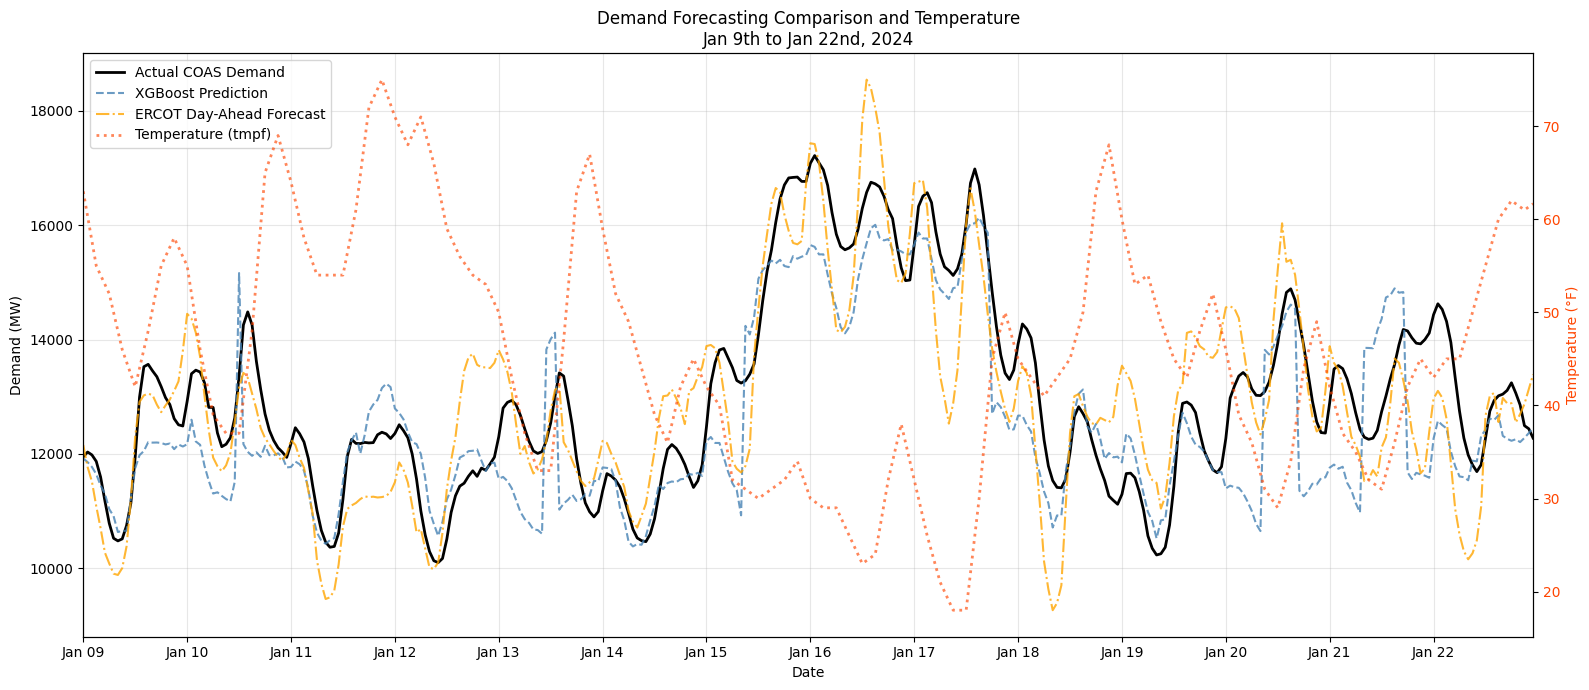

In [774]:
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Compute error vectors (same as before)
error_df = pd.DataFrame({
    "actual": y_test,
    "xgb_pred": y_pred,  # Using the predictions from best_xgb_model
}).join(ercot_forecast, how="inner")

error_df["xgb_error"]  = error_df["xgb_pred"] - error_df["actual"]
error_df["ercot_error"] = error_df["ercot_forecast"] - error_df["actual"]

error_df["abs_xgb_error"]  = error_df["xgb_error"].abs()
error_df["abs_ercot_error"] = error_df["ercot_error"].abs()

error_df["xgb_wins"] = (error_df["abs_xgb_error"] < error_df["abs_ercot_error"]).astype(int)

xgb_mae  = error_df["abs_xgb_error"].mean()
ercot_mae = error_df["abs_ercot_error"].mean()
win_rate  = error_df["xgb_wins"].mean() * 100

print(f"Hours compared:    {len(error_df)}")
print(f"XGBoost MAE:       {xgb_mae:.1f} MW")
print(f"ERCOT   MAE:       {ercot_mae:.1f} MW")
print(f"XGBoost win rate:  {win_rate:.1f}%\n")

# --- NEW: Plot the two weeks starting January 9th on the same graph, overlay tmpf with its own axis ---

start_dt = pd.Timestamp("2024-01-09 00:00:00")
end_dt = pd.Timestamp("2024-01-23 00:00:00")    # up to but not including Jan 23
period_mask = (error_df.index >= start_dt) & (error_df.index < end_dt)
two_week_df = error_df.loc[period_mask].copy()

if len(two_week_df) == 0:
    print("No data found for the window Jan 9 - Jan 22.")
else:
    # If "tmpf" is not yet joined onto error_df, fetch from X and join
    if "tmpf" not in two_week_df.columns:
        # This expects X (the feature matrix for y_test) to have a "tmpf" column aligned to y_test's index
        # If X is not available, you may need to join from another source
        try:
            tmpf_series = X.loc[two_week_df.index, "tmpf"]
            two_week_df["tmpf"] = tmpf_series
        except Exception as e:
            print("Unable to find 'tmpf' in X:", e)
            two_week_df["tmpf"] = np.nan
    
    import matplotlib.dates as mdates

    fig, ax1 = plt.subplots(figsize=(16, 7))

    # Demand forecast lines (shared axis)
    ax1.plot(two_week_df.index, two_week_df["actual"], label="Actual COAS Demand", color="black", linewidth=2)
    ax1.plot(two_week_df.index, two_week_df["xgb_pred"], label="XGBoost Prediction", color="steelblue", alpha=0.8, linestyle="--")
    ax1.plot(two_week_df.index, two_week_df["ercot_forecast"], label="ERCOT Day-Ahead Forecast", color="orange", alpha=0.8, linestyle="-.")

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Demand (MW)")
    ax1.grid(True, alpha=0.3)

    # Right y-axis for temperature
    ax2 = ax1.twinx()
    ax2.plot(two_week_df.index, two_week_df["tmpf"], label="Temperature (tmpf)", color="orangered", linestyle=":", linewidth=2, alpha=0.65)
    ax2.set_ylabel("Temperature (°F)", color="orangered")
    ax2.tick_params(axis="y", labelcolor="orangered")

    # Combine legends (for both axes)
    demand_handles, demand_labels = ax1.get_legend_handles_labels()
    tmpf_handles, tmpf_labels = ax2.get_legend_handles_labels()
    ax1.legend(demand_handles + tmpf_handles, demand_labels + tmpf_labels, loc="upper left")

    # Set daily ticks for x-axis
    ax1.xaxis.set_major_locator(mdates.DayLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    # Clip the x-axis to just cover the data
    ax1.set_xlim([two_week_df.index.min(), two_week_df.index.max()])

    plt.title("Demand Forecasting Comparison and Temperature\nJan 9th to Jan 22nd, 2024")
    plt.tight_layout()
    plt.show()

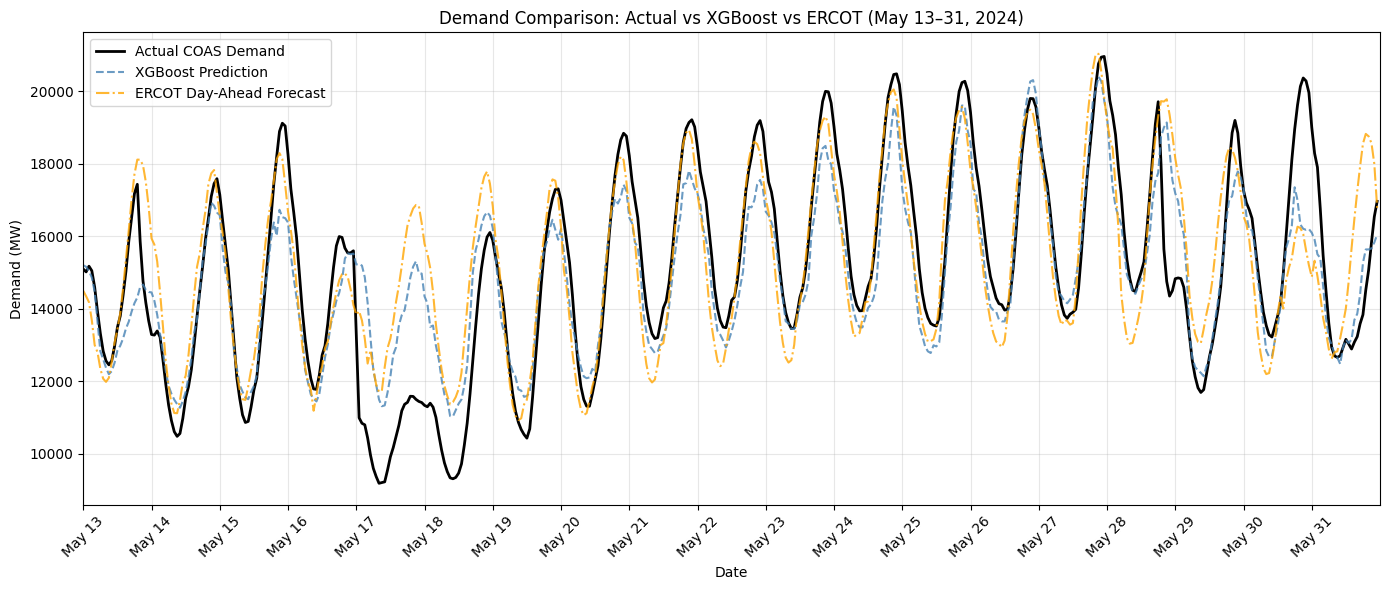

In [775]:
# Plot the period May 13th - May 31st, 2024 for 'actual', 'xgb_pred', and 'ercot_forecast'

import matplotlib.dates as mdates

may_source = error_df.copy()

# It's 2024, not 2023, you dumb IDIOT
if not isinstance(may_source.index, pd.DatetimeIndex):
    if "period" in may_source.columns:
        may_source["period"] = pd.to_datetime(may_source["period"], errors="coerce")
        may_source = may_source.set_index("period")
    elif "datetime" in may_source.columns:
        may_source["datetime"] = pd.to_datetime(may_source["datetime"], errors="coerce")
        may_source = may_source.set_index("datetime")
    else:
        print("Could not plot May window: no DatetimeIndex and no 'period'/'datetime' column found.")
        may_source = None

if may_source is not None:
    may_source = may_source.sort_index()
    may_source = may_source[~may_source.index.isna()]

    required_cols = ["actual", "xgb_pred", "ercot_forecast"]
    missing_cols = [c for c in required_cols if c not in may_source.columns]

    if missing_cols:
        print(f"Could not plot May window: missing columns {missing_cols}")
    else:
        # Define date range for May 13th - May 31st, 2024
        may_start = pd.Timestamp("2024-05-13 00:00:00")
        may_end = pd.Timestamp("2024-05-31 23:59:59")

        may_df = may_source.loc[may_start:may_end, required_cols]

        if may_df.empty:
            print(
                f"No rows found between {may_start} and {may_end}. "
                f"Available range: {may_source.index.min()} to {may_source.index.max()}"
            )
        else:
            fig, ax = plt.subplots(figsize=(14, 6))

            ax.plot(may_df.index, may_df["actual"], label="Actual COAS Demand", color="black", linewidth=2)
            ax.plot(may_df.index, may_df["xgb_pred"], label="XGBoost Prediction", color="steelblue", linestyle="--", alpha=0.8)
            ax.plot(may_df.index, may_df["ercot_forecast"], label="ERCOT Day-Ahead Forecast", color="orange", linestyle="-.", alpha=0.8)

            ax.set_xlabel("Date")
            ax.set_ylabel("Demand (MW)")
            ax.set_title("Demand Comparison: Actual vs XGBoost vs ERCOT (May 13–31, 2024)")
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
            plt.xticks(rotation=45)
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_xlim(may_start, may_end)
            plt.tight_layout()
            plt.show()

# 3. Analyzing error patterns

We first graph out our most telling features, these contribute the most to our predictions and are fairly intuitive.

<Figure size 1000x800 with 0 Axes>

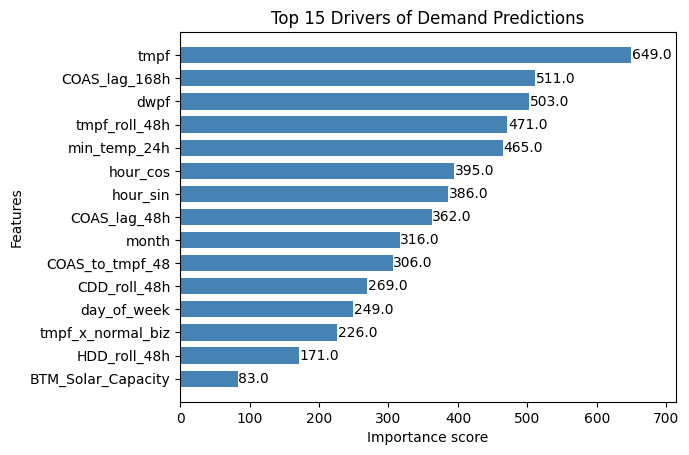

In [776]:
# Feature Importance Plot
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb_model, max_num_features=15, height=0.7, color='steelblue', grid=False)
plt.title("Top 15 Drivers of Demand Predictions")
plt.show()

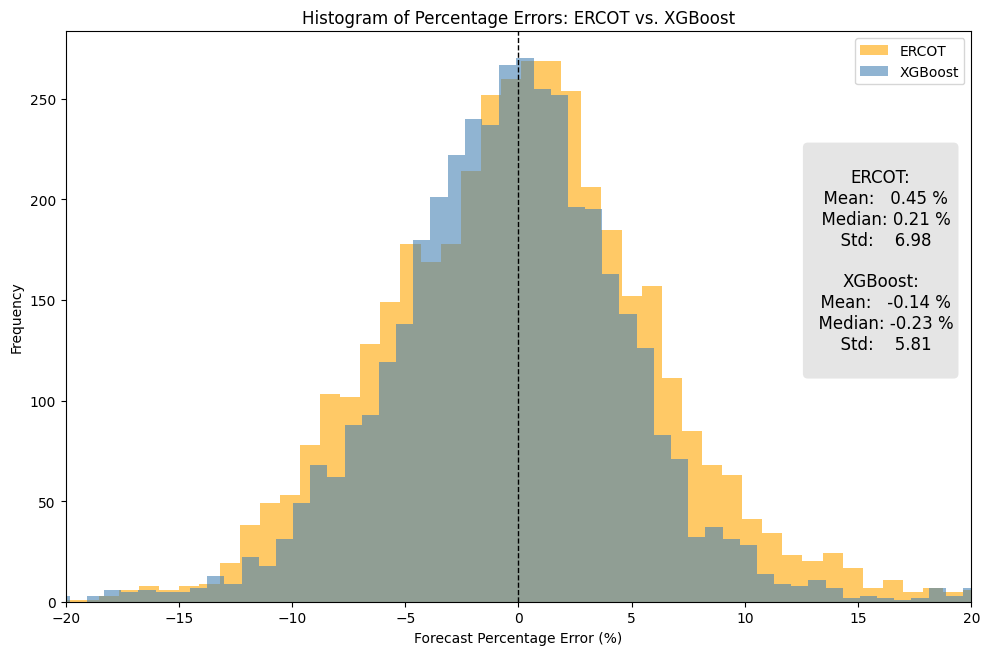

In [777]:
# Plot histograms of the percentage errors for both ERCOT and XGBoost, and include stats box per model

import numpy as np

# Calculate percentage errors
error_df['ercot_pct_error'] = (error_df['ercot_forecast'] - error_df['actual']) / error_df['actual'] * 100
error_df['xgb_pct_error'] = (error_df['xgb_pred'] - error_df['actual']) / error_df['actual'] * 100

# Compute required statistics for each model
stats = {}
for label, col in [('ERCOT', 'ercot_pct_error'), ('XGBoost', 'xgb_pct_error')]:
    arr = error_df[col].dropna()
    stats[label] = {
        'mean': arr.mean(),
        'median': arr.median(),
        'std': arr.std(),
    }

# Create a square plot
plt.figure(figsize=(10, 6.66))
plt.hist(error_df['ercot_pct_error'].dropna(), bins=80, alpha=0.6, label='ERCOT', color='orange')
plt.hist(error_df['xgb_pct_error'].dropna(), bins=80, alpha=0.6, label='XGBoost', color='steelblue')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Histogram of Percentage Errors: ERCOT vs. XGBoost")
plt.xlabel("Forecast Percentage Error (%)")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(-20, 20)

# Create stat box text
stats_text = ""
for label in ['ERCOT', 'XGBoost']:
    stats_text += "\n"
    stats_text += f"{label}:\n"
    stats_text += f"  Mean:   {stats[label]['mean']:.2f} %\n"
    stats_text += f"  Median: {stats[label]['median']:.2f} %\n"
    stats_text += f"  Std:    {stats[label]['std']:.2f}\n"

# Put the stats box in the lower right of the plot
plt.gca().text(
    0.9, 0.4,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='bottom',
    horizontalalignment='center',
    bbox=dict(boxstyle='round', facecolor='grey', alpha=0.2, edgecolor='none')
)

plt.tight_layout()

# Save as high quality
plt.savefig('error_histogram.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

Then we plot the hourly head-to-head victor between our XGBoost model and the ERCOT prediction.

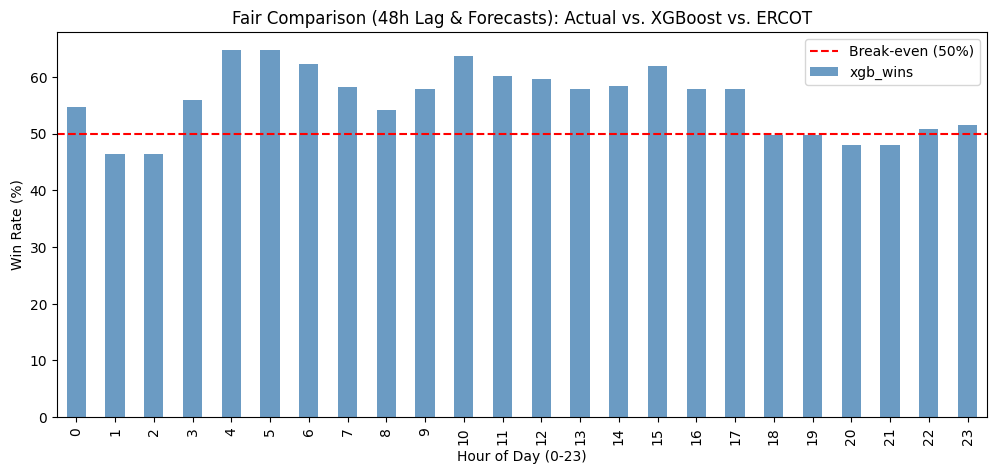

In [778]:
# Hourly Win Rate
error_df['hour'] = error_df.index.hour
hourly_win_rate = error_df.groupby('hour')['xgb_wins'].mean() * 100

plt.figure(figsize=(12, 5))
hourly_win_rate.plot(kind='bar', color='steelblue', alpha=0.8)
plt.axhline(50, color='red', linestyle='--', label='Break-even (50%)')
plt.title("Fair Comparison (48h Lag & Forecasts): Actual vs. XGBoost vs. ERCOT")
plt.ylabel("Win Rate (%)")
plt.xlabel("Hour of Day (0-23)")
plt.legend()
plt.show()

This plot is basically a "stress test" for the models.

**AI explanation**:
Our model achieved an R² of 0.899, while ERCOT sits at 0.825. In simple terms, this means our model explains roughly 90% of the variance in demand, whereas ERCOT only explains about 82%


**Our Model (Left)**: The blue dots are more tightly hugged against the red line. This suggests that our errors are consistent and smaller.

**ERCOT (Right)**: The orange dots show more vertical "smearing," especially in the middle-demand range. This indicates that for the same actual load level, ERCOT’s model produces a wider range of incorrect guesses.

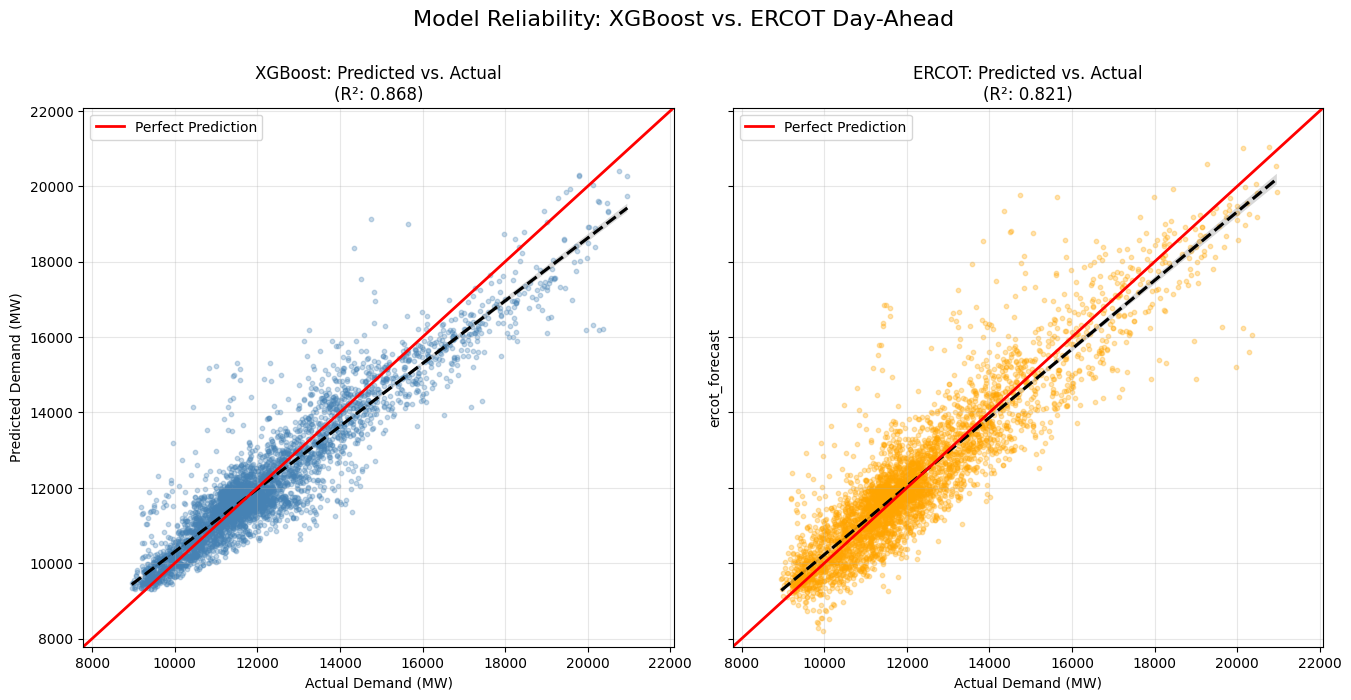

--- Peak Demand Analysis (Top 10% of Loads > 14858 MW) ---
XGBoost Peak MAE: 940.2 MW
ERCOT Peak MAE:   909.7 MW
Improvement:      -3.3%


In [779]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 1. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.1)

# Define plot limits for a perfect square comparison
min_val = min(error_df['actual'].min(), error_df['xgb_pred'].min(), error_df['ercot_forecast'].min()) * 0.95
max_val = max(error_df['actual'].max(), error_df['xgb_pred'].max(), error_df['ercot_forecast'].max()) * 1.05

# 2. XGBoost Scatter Plot
sns.regplot(x='actual', y='xgb_pred', data=error_df, ax=ax1,
            scatter_kws={'alpha':0.3, 'color':'steelblue', 's':10},
            line_kws={'color':'black', 'linestyle':'--'})
ax1.set_title(f"XGBoost: Predicted vs. Actual\n(R²: {r2_score(error_df['actual'], error_df['xgb_pred']):.3f})")
ax1.set_xlabel("Actual Demand (MW)")
ax1.set_ylabel("Predicted Demand (MW)")

# 3. ERCOT Scatter Plot
sns.regplot(x='actual', y='ercot_forecast', data=error_df, ax=ax2,
            scatter_kws={'alpha':0.3, 'color':'orange', 's':10},
            line_kws={'color':'black', 'linestyle':'--'})
ax2.set_title(f"ERCOT: Predicted vs. Actual\n(R²: {r2_score(error_df['actual'], error_df['ercot_forecast']):.3f})")
ax2.set_xlabel("Actual Demand (MW)")

# 4. Add "Perfect Prediction" Identity Lines
for ax in [ax1, ax2]:
    ax.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, label='Perfect Prediction')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Model Reliability: XGBoost vs. ERCOT Day-Ahead", fontsize=16, y=1.02)

# Save as extremely high quality
plt.savefig('model_reliability.png', dpi=1200, bbox_inches='tight', transparent=True)
plt.show()

# 5. Print a Peak-Load Gap Analysis
peak_threshold = error_df['actual'].quantile(0.90)
xgb_peak_mae = error_df[error_df['actual'] > peak_threshold]['abs_xgb_error'].mean()
ercot_peak_mae = error_df[error_df['actual'] > peak_threshold]['abs_ercot_error'].mean()

print(f"--- Peak Demand Analysis (Top 10% of Loads > {peak_threshold:.0f} MW) ---")
print(f"XGBoost Peak MAE: {xgb_peak_mae:.1f} MW")
print(f"ERCOT Peak MAE:   {ercot_peak_mae:.1f} MW")
print(f"Improvement:      {((ercot_peak_mae - xgb_peak_mae) / ercot_peak_mae)*100:.1f}%")

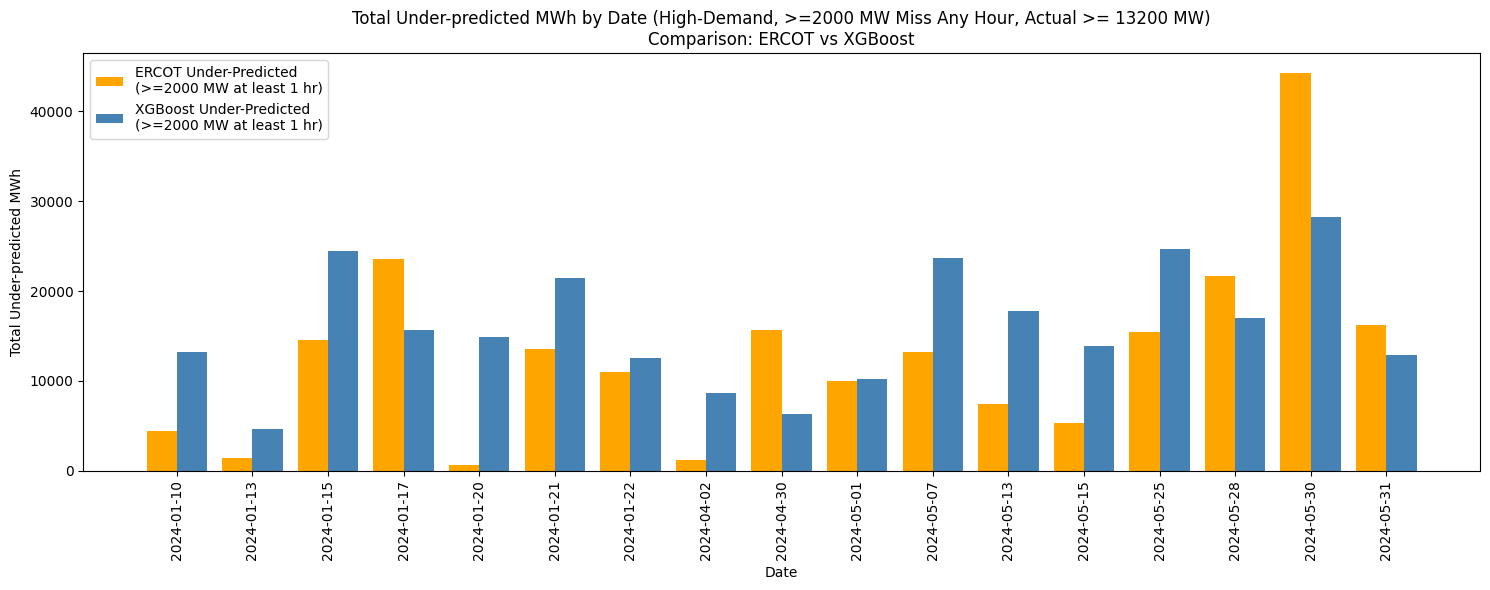

In [785]:
# Compare days where ERCOT vs XGBoost under-predict,
# keeping only days with at least one hour of underprediction >= 2000 MW at high demand.

critical_threshold = 13200
underprediction_threshold = 2000

# Build a clean working frame (avoids SettingWithCopyWarning and index alignment issues)
base = error_df.copy()

# Robust datetime -> date extraction
if 'period' in base.columns:
    ts = pd.to_datetime(base['period'], errors='coerce')
else:
    ts = pd.to_datetime(base.index, errors='coerce')

if 'period' in base.columns:
    ts = pd.to_datetime(base['period'], errors='coerce').dt.date
else:
    ts = pd.to_datetime(base.index, errors='coerce').date

base = base.assign(date=ts).dropna(subset=['date'])
# Hourly underprediction magnitudes (only positive underprediction)
base['ercot_under_mw'] = (base['actual'] - base['ercot_forecast']).clip(lower=0)
base['xgb_under_mw'] = (base['actual'] - base['xgb_pred']).clip(lower=0)

# Trigger condition: high-demand hour + at least one large miss
high_demand = base['actual'] >= critical_threshold
ercot_trigger = high_demand & (base['ercot_under_mw'] >= underprediction_threshold)
xgb_trigger = high_demand & (base['xgb_under_mw'] >= underprediction_threshold)

# Dates where either model had at least one trigger hour
dates_of_interest = sorted(
    set(base.loc[ercot_trigger, 'date']) | set(base.loc[xgb_trigger, 'date'])
)

# Aggregate total daily underprediction across all high-demand hours on selected dates
if dates_of_interest:
    selected = base.loc[
        base['date'].isin(dates_of_interest) & high_demand,
        ['date', 'ercot_under_mw', 'xgb_under_mw']
    ].copy()

    ercot_daily_under = selected.groupby('date')['ercot_under_mw'].sum().sort_index()
    xgb_daily_under = selected.groupby('date')['xgb_under_mw'].sum().sort_index()
else:
    ercot_daily_under = pd.Series(dtype=float)
    xgb_daily_under = pd.Series(dtype=float)

all_dates = sorted(set(ercot_daily_under.index) | set(xgb_daily_under.index))
ercot_vals = ercot_daily_under.reindex(all_dates, fill_value=0).values
xgb_vals = xgb_daily_under.reindex(all_dates, fill_value=0).values

plt.figure(figsize=(15, 6))
width = 0.4
x = np.arange(len(all_dates))
dates_str = [str(d) for d in all_dates]

plt.bar(x - width / 2, ercot_vals, width=width, color='orange',
        label='ERCOT Under-Predicted\n(>=2000 MW at least 1 hr)')
plt.bar(x + width / 2, xgb_vals, width=width, color='steelblue',
        label='XGBoost Under-Predicted\n(>=2000 MW at least 1 hr)')

plt.xlabel("Date")
plt.ylabel("Total Under-predicted MWh")
plt.title(
    f"Total Under-predicted MWh by Date (High-Demand, >=2000 MW Miss Any Hour, Actual >= {critical_threshold} MW)\n"
    "Comparison: ERCOT vs XGBoost"
)
plt.xticks(x, dates_str, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [781]:
# Prove Robustness with Segmented Metrics
def get_season(month):
    if month in [6, 7, 8]: return 'Summer'
    elif month in [12, 1, 2]: return 'Winter'
    else: return 'Shoulder'

error_df['Season'] = error_df.index.month.map(get_season)

top_5_pct = error_df['actual'].quantile(0.95)
bottom_50_pct = error_df['actual'].quantile(0.50)

def get_tier(load):
    if load >= top_5_pct: return 'Top 5% (Peak)'
    elif load <= bottom_50_pct: return 'Bottom 50% (Base)'
    else: return 'Middle 45%'

error_df['Load_Tier'] = error_df['actual'].map(get_tier)

season_metrics = error_df.groupby('Season').agg(
    XGB_MAE=('abs_xgb_error', 'mean'),
    ERCOT_MAE=('abs_ercot_error', 'mean'),
    XGB_Win_Rate=('xgb_wins', lambda x: x.mean() * 100)
).round(1)

tier_metrics = error_df.groupby('Load_Tier').agg(
    XGB_MAE=('abs_xgb_error', 'mean'),
    ERCOT_MAE=('abs_ercot_error', 'mean'),
    XGB_Win_Rate=('xgb_wins', lambda x: x.mean() * 100)
).round(1)

print("\n--- Metrics by Season ---")
print(season_metrics)
print("\n--- Metrics by Load Tier ---")
print(tier_metrics)


--- Metrics by Season ---
          XGB_MAE  ERCOT_MAE  XGB_Win_Rate
Season                                    
Shoulder    543.5      650.2          56.4
Winter      503.0      577.3          55.3

--- Metrics by Load Tier ---
                   XGB_MAE  ERCOT_MAE  XGB_Win_Rate
Load_Tier                                          
Bottom 50% (Base)    400.8      546.7          60.0
Middle 45%           585.4      660.6          53.6
Top 5% (Peak)       1218.0      919.6          35.0
